# Python Controle Discret

In [1]:
from Models.BallBeam import ballbeam_config
from Models.BallBeam.StateSpace import StateSpaceModel
from Models.BallBeam.TransferFunctions import TransferFunctionModel

from Simulation.simulation import TFSimulator
from Simulation.simulation import HybridSim

from Simulation.runners import *

from Metrics_Plotting.SimLog import SimLog
from Metrics_Plotting.Plotting import Plotting

from Control.DiscretePID import DiscretePID
from Control.RSTController import RSTController

import numpy as np
import control as ct
import matplotlib.pyplot as plt



In [2]:
%matplotlib inline

## Mise en place

#### Système
Ici, on spécifie l'état initial, la méthode TransferFunctionModel() donne sa fonction de tranfert qu'on met ensuite dans le simualteur de fonctions de transfert

In [3]:
X_0 = np.array([[0], [0]])
model = TransferFunctionModel(ballbeam_config)
plant_sim = TFSimulator(model.Tf_dis, 0)

Les paramètres de la simulation (Temps total et période d'échantillonage se trouvent dans le fichier Models/Ballbeam/ballbeam_config.py) mais elles peuvent etre changés dirrectement dans le notebook. Par défaut le temps de simulation T est à 3 secondes et le temps d'échantillonage à 20 ms.

In [4]:
#ballbeam_config.dt=0.1 

#### Réponse inditielle et impultionelle 
Le but est de comparer notre simualtion a celle de la librairie python

1) Réponse impulsionelle

In [5]:
## simulateur 
impulse_logger=SimLog()
impulse_logger=run_discrete_impulse_response(plant_sim,ballbeam_config,0.0,impulse_logger)
## librairie python
t = np.arange(0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib = ct.impulse_response(model.Tf_dis, t)

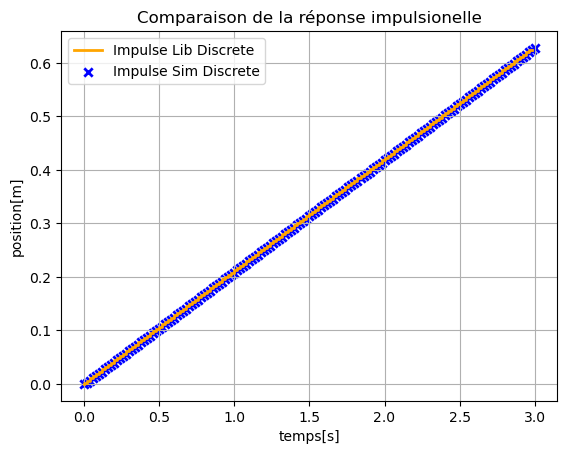

In [6]:
## affichage
fig1=plt.figure()
plt.step(
    t,
    y_lib,
    color='orange',
    linewidth=2,
    label="Impulse Lib Discrete"
)
plt.scatter(
    impulse_logger.t_hist,
    impulse_logger.y_hist,
    color='blue',
    marker='x',
    label="Impulse Sim Discrete",
    linewidth=2,
)


plt.grid()
plt.title('Comparaison de la réponse impulsionelle')
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')
#plt.savefig('Réponse_Impulsionelle_Discrete.png')
plt.show()


##### Réponse inditielle
Ici aussi, on utilise les run... pour simuler la réponse inditielle. Pour cela, on créé une nouvelle instance de SimLog

In [7]:
## simulateur 
step_logger=SimLog()
step_logger=run_discrete_step_response(plant_sim,ballbeam_config,0.0,step_logger)
## librairie python
t = np.arange(0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib = ct.step_response(model.Tf_dis, t)

In [8]:
_, y_lib = ct.step_response(model.Tf_cont, t)

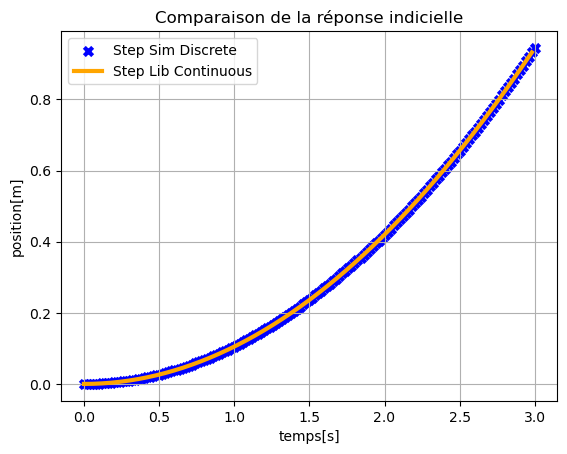

In [9]:
fig3=plt.figure()
plt.scatter(
    step_logger.t_hist,
    step_logger.y_hist,
    color='blue',
    marker='x',
    label="Step Sim Discrete",
    linewidth=3,
)

plt.plot(
    t,
    y_lib,
    color='orange',
    linestyle='-',
    linewidth=3,
    label="Step Lib Continuous"
)
plt.grid()
plt.title('Comparaison de la réponse indicielle')
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')
#plt.savefig('Réponse_Indicielle_Continue.png')
plt.show()


## Controle PID et validation


#### Mise en place du PID
On peut changer la duréé de simulation en mettant ballbeam_config.T= varaible . L'instance du PID discret est initalisé avec DiscretePID().

In [10]:
ballbeam_config.T=6

#### Modele en espace d'états (utilisé pour la simulation hybride)
Pour initailiser le simulateur continu, on lui met en entrée le ficher python contenant les matrices d'état 

In [11]:
StateSpace_Ball_Beam=StateSpaceModel(ballbeam_config)
hybrid_loop=HybridSim(StateSpace_Ball_Beam,ballbeam_config)


La fonction run_continuous_step_response prends en entrée le simulateur continu, l'état initial du système, et l'enregistreur 

In [12]:
logger_hybrid_step = SimLog()
logger_hybrid_step = run_continuous_step_response(hybrid_loop, X_0,logger_hybrid_step)

In [13]:
t = np.arange(0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib1 = ct.step_response(model.Tf_cont, t)

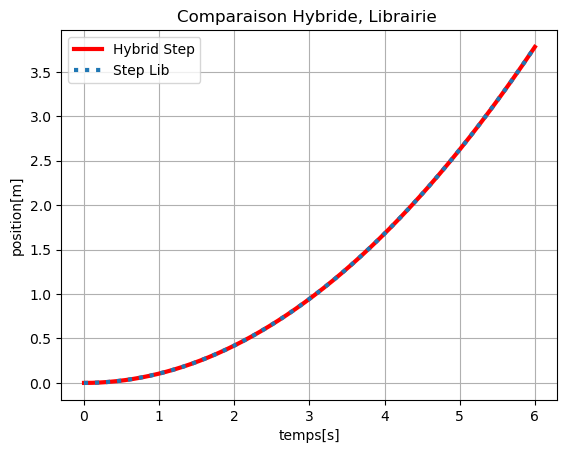

In [14]:
plt.figure()

plt.plot(
    logger_hybrid_step.t_hist,
    logger_hybrid_step.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid Step"
)
plt.plot(
    t,
    y_lib1,
    linestyle=':',
    linewidth=3,
    label="Step Lib"
)
plt.title("Comparaison Hybride, Librairie ")
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')
#plt.savefig('Réponse_Indicielle_Hybride.png')
plt.show()

La boucle fermée hybride est simulée par run_continuous_control_loop(), tout controleur qui est mis en entrée de cette fonction doit avoir la méthode setReference() et step().
Pour configurer le PID, il lui faut l'initialiser avec ses paramètres.

In [15]:
kp, ki, kd = 150,100, 100
r = 1.0
PID = DiscretePID(kp,ki,kd,ballbeam_config.dt)
#PID.reset()

In [16]:
logger_hybrid = SimLog()
logger_hybrid = run_continuous_control_loop(hybrid_loop,PID,r,X_0,logger_hybrid)


u_k- 2650.0 y_k- 0.0
u_k- 1107.0550000000003 y_k- 0.11130000000000001
u_k- -90.14782149999974 y_k- 0.38039630999999974
u_k- -821.7627170870492 y_k- 0.6922027214969994
u_k- -1109.4640119311052 y_k- 0.9657088903733432
u_k- -1059.1213021383892 y_k- 1.158103536630925
u_k- -807.3664984383028 y_k- 1.2594175996975876
u_k- -481.7082907768365 y_k- 1.2823391751400288
u_k- -177.4295418152247 y_k- 1.2511196094354344
u_k- 50.193440817190776 y_k- 1.1922162547619737
u_k- 182.45074887490162 y_k- 1.1279689838465952
u_k- 227.4409281967483 y_k- 1.073492768898285
u_k- 208.38177376677118 y_k- 1.0362320043869837
u_k- 153.140715921715 y_k- 1.0172757933581502
u_k- 86.7061301416905 y_k- 1.0135035268962336
u_k- 27.06707200903236 y_k- 1.0198048279689793
u_k- -15.914118166170852 y_k- 1.0308846035320558
u_k- -39.51898456280867 y_k- 1.0424328031565324
u_k- -46.07180940200911 y_k- 1.051652812466392
u_k- -40.57433997334054 y_k- 1.057278008429729
u_k- -28.666681735174016 y_k- 1.0592640661193018
u_k- -15.21653135045938

In [17]:
L = PID.transferFunction * model.Tf_dis
T = ct.feedback(L, 1)

t = np.arange(
    0,
    ballbeam_config.T,
    ballbeam_config.dt
)

_, y_lib = ct.step_response(T, t)

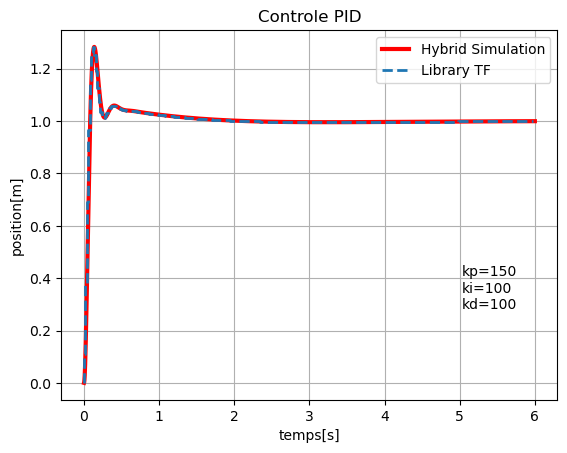

In [18]:
plt.figure()

plt.plot(
    logger_hybrid.t_hist,
    logger_hybrid.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid Simulation"
)
plt.step(t, y_lib, label="Library TF",linewidth=2,
    linestyle='--',)
plt.title("Controle PID")
text='kp='+str(kp)+'\n'+'ki='+str(ki)+'\n'+'kd='+str(kd)
plt.figtext(0.75,0.3,text)
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Réponse_Indicielle_PID.png')
plt.show()


Outil pour exporter un enregistreur sous forme de fichier CSV

In [19]:
from Utils import utils
#utils.as_csv('hybridLog',logger_hybrid)

Controle RST, les polynomes R, S et T doivent etre entrés dans RSTController() \
Ici, on a utilisé le PID discret changé en structure RST

In [20]:
rst=RSTController(PID.R,PID.S,PID.T)
logger_rst = SimLog()
logger_rst = run_continuous_control_loop(hybrid_loop,rst,r,X_0,logger_rst)

u_k- 2650.0 y_k- 0.0
u_k- 1107.0549999999998 y_k- 0.11130000000000001
u_k- -90.14782149999951 y_k- 0.38039630999999974
u_k- -821.7627170870488 y_k- 0.6922027214969994
u_k- -1109.4640119311048 y_k- 0.9657088903733432
u_k- -1059.1213021383883 y_k- 1.158103536630925
u_k- -807.3664984383029 y_k- 1.2594175996975876
u_k- -481.70829077683766 y_k- 1.2823391751400288
u_k- -177.42954181522634 y_k- 1.2511196094354344
u_k- 50.1934408171889 y_k- 1.1922162547619737
u_k- 182.45074887489974 y_k- 1.1279689838465952
u_k- 227.44092819674822 y_k- 1.073492768898284
u_k- 208.38177376677123 y_k- 1.0362320043869822
u_k- 153.1407159217149 y_k- 1.0172757933581482
u_k- 86.70613014169223 y_k- 1.0135035268962305
u_k- 27.067072009032188 y_k- 1.0198048279689762
u_k- -15.914118166171718 y_k- 1.0308846035320525
u_k- -39.51898456280852 y_k- 1.0424328031565286
u_k- -46.071809402007396 y_k- 1.0516528124663875
u_k- -40.574339973339235 y_k- 1.0572780084297244
u_k- -28.66668173517172 y_k- 1.0592640661192965
u_k- -15.2165313

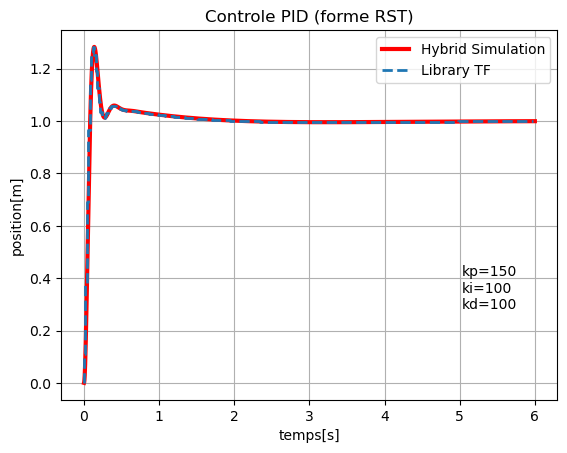

In [21]:
plt.figure()

plt.plot(
    logger_rst.t_hist,
    logger_rst.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid Simulation"
)
plt.step(t, y_lib, label="Library TF",linewidth=2,
    linestyle='--',)
plt.title("Controle PID (forme RST)")
text='kp='+str(kp)+'\n'+'ki='+str(ki)+'\n'+'kd='+str(kd)
plt.figtext(0.75,0.3,text)
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Réponse_Indicielle_PID.png')
plt.show()


In [22]:
logger_discrete_control=SimLog()
logger_discrete_control=run_discrete_control(plant_sim,rst,ballbeam_config,1.0,0,logger_discrete_control)

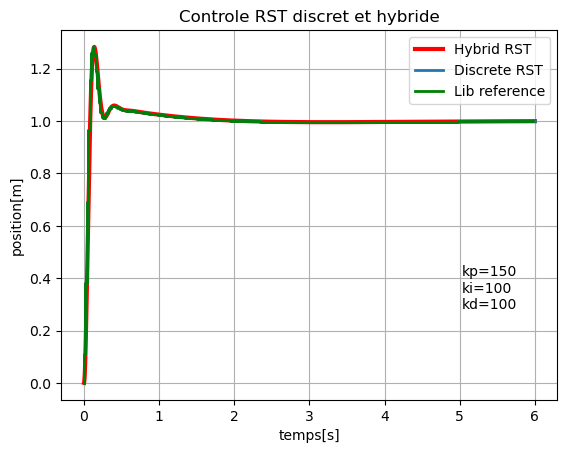

In [23]:
plt.figure()

plt.plot(
    logger_rst.t_hist,
    logger_rst.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid RST"
)
plt.step(logger_discrete_control.t_hist, logger_discrete_control.y_hist, label="Discrete RST",linewidth=2,
    linestyle='-',)
plt.step(t,y_lib,label="Lib reference",color="green",linewidth=2,
    linestyle='-',)
plt.title("Controle RST discret et hybride")
text='kp='+str(kp)+'\n'+'ki='+str(ki)+'\n'+'kd='+str(kd)
plt.figtext(0.75,0.3,text)
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Comparaision_hybride_discret_simu.png')
plt.show()


RST avec fonction de transfert en BF désirée 

In [24]:
omega_n = 0.3  # Natural frequency in rad/s
zeta = 0.1 # Damping ratio (optimal balance of speed and overshoot)

# Standard second-order form: omega_n^2 / (s^2 + 2*zeta*omega_n*s + omega_n^2)
num_cl = [omega_n**2]
den_cl = [1, 2 * zeta * omega_n, omega_n**2]
G_cl_continuous = ct.tf(num_cl, den_cl)

# Discretize the desired tracking target
desired_discrete = ct.c2d(G_cl_continuous,ballbeam_config.dt, method="zoh")
print(desired_discrete)


<TransferFunction>: sys[21]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

  1.799e-05 z + 1.799e-05
  -----------------------
  z^2 - 1.999 z + 0.9988


In [25]:
R,S,T=utils.Compute_Desired_RST(desired_discrete,model.Tf_dis)


--- RST synthesis complete ---
S: [9.99689686e-01 2.98320682e-04]
R: [ 7.38842945  0.14275703 -7.10287338]
T: [0.42839877]

Closed-loop TF check:
<TransferFunction>: sys[26]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

         1.799e-05 z + 1.799e-05
  --------------------------------------
  z^3 - 1.999 z^2 + 0.9988 z - 2.899e-16


In [26]:
rst_2=RSTController(R,S,T)
logger_rst_test = SimLog()
logger_rst_test = run_continuous_control_loop(hybrid_loop,rst_2,1.0,X_0,logger_rst_test)

u_k- 0.057982385709654624 y_k- 0.0
u_k- 0.05686173780924718 y_k- 2.4352601998054957e-06
u_k- 0.11262382771041589 y_k- 9.693973587404869e-06
u_k- 0.11046712774315554 y_k- 2.40710807268301e-05
u_k- 0.16411252112020347 y_k- 4.781800799530533e-05
u_k- 0.16099788090678444 y_k- 8.309728051604165e-05
u_k- 0.2126234864261919 y_k- 0.00013203118992191151
u_k- 0.2086229834545604 y_k- 0.00019665719675576642
u_k- 0.25831946219405927 y_k- 0.0002789755553246128
u_k- 0.25349955951848774 y_k- 0.0003809054966107011
u_k- 0.30135173905637347 y_k- 0.0005043318368087164
u_k- 0.295773677395427 y_k- 0.0006510619315468757
u_k- 0.3418609388761396 y_k- 0.0008228712937760108
u_k- 0.33558110275758607 y_k- 0.001021461309888552
u_k- 0.3799777427221675 y_k- 0.0012485038917497099
u_k- 0.3730480023997663 y_k- 0.0015055999451210173
u_k- 0.41582357105078654 y_k- 0.0017943230797874458
u_k- 0.4082916018029596 y_k- 0.0021161788205387977
u_k- 0.44951121926239634 y_k- 0.0024726473985500056
u_k- 0.44142079957549113 y_k- 0.0028

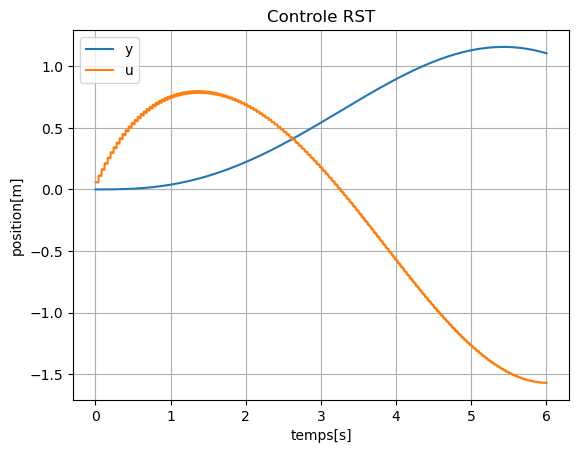

In [27]:
plt.figure()
plt.plot(logger_rst_test.t_hist, logger_rst_test.y_hist, label="y")
plt.plot(logger_rst_test.t_hist, logger_rst_test.u_hist, label="u")

plt.title("Controle RST")
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Réponse_Indicielle_PID.png')
plt.show()

In [28]:
utils.as_csv('RSTLog',logger_rst_test)

In [29]:
from sklearn.preprocessing import scale


def make_desired_tf_compatible(plant_tf, pole_radius=0.85, dc_gain=1.0):
    """Build a Desired TF compatible with Compute_Desired_RST.
    - pole_radius: 0<r<1 place all desired poles at r (slower if r closer to 1)
    - dc_gain: closed-loop DC gain (scales B_cl = dc_gain * B)
    """
    # Extract plant polynomials (trim leading zeros)
    A = np.trim_zeros(np.asarray(plant_tf.den_list[0][0]), 'f')
    B = np.trim_zeros(np.asarray(plant_tf.num_list[0][0]), 'f')
    dc_gain_target=1.0
    deg_A = len(A) - 1
    deg_B = len(B) - 1
    desired_deg = deg_A + deg_B

    poles = [pole_radius] * desired_deg if desired_deg > 0 else [pole_radius]
    A_cl = np.poly(poles)  # closed-loop denominator

    sumB = float(np.sum(B))
    sumAcl = float(np.sum(A_cl))

    if abs(sumB) < 1e-12:
        # fallback: avoid division by tiny plant DC gain
        scale = float(dc_gain_target)
    else:
        scale = float(dc_gain_target) * (sumAcl / sumB)

    B_cl = scale * B

    return ct.tf(B_cl, A_cl, plant_tf.dt)

# --- Example usage (assumes imports and models already present above in the notebook) ---
plant = TransferFunctionModel(ballbeam_config)
Desired_TF = make_desired_tf_compatible(plant.Tf_dis, pole_radius=0.88, dc_gain=1.0)
print('Plant TF:')
print(plant.Tf_dis)
print('\nDesired TF:')
print(Desired_TF)

# Run synthesis using your existing Compute_Desired_RST
S_tf, R_tf, T_tf = utils.Compute_Desired_RST(Desired_TF, plant.Tf_dis)
print('\nS =', S_tf)
print('R =', R_tf)
print('T =', T_tf)


Plant TF:
<TransferFunction>: sys[28]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

  4.2e-05 z + 4.2e-05
  -------------------
     z^2 - 2 z + 1

Desired TF:
<TransferFunction>: sys[30]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

        0.000864 z + 0.000864
  ---------------------------------
  z^3 - 2.64 z^2 + 2.323 z - 0.6815

--- RST synthesis complete ---
S: [ 0.98956  -0.671608]
R: [ 248.5714308     6.85713841 -234.85714063]
T: [20.57142857]

Closed-loop TF check:
<TransferFunction>: sys[34]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

        0.000864 z + 0.000864
  ---------------------------------
  z^3 - 2.64 z^2 + 2.323 z - 0.6815

S = <TransferFunction>: sys[31]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

  0.9896 z - 0.6716
  -----------------
          1
R = <TransferFunction>: sys[32]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

  248.6 z^2 + 6.857 z - 234.9
  ---------------------------
               1
T = <Trans

u_k- 20.788460096788707 y_k- 0.0
u_k- 34.67813286708533 y_k- 0.0008731153240651258
u_k- 43.29441234313129 y_k- 0.004075827552612962
u_k- 47.70013005062534 y_k- 0.010553386679989903
u_k- 48.81836280451944 y_k- 0.020852716587904625
u_k- 47.437869354624574 y_k- 0.03520582319573544
u_k- 44.22493852685429 y_k- 0.053601691554250305
u_k- 39.73537697635114 y_k- 0.07584739784378729
u_k- 34.42639213181409 y_k- 0.10161943738445887
u_k- 28.668117963745832 y_k- 0.13050627122767336
u_k- 22.754595981787276 y_k- 0.16204307449490135
u_k- 16.914077823994667 y_k- 0.19573963174784165
u_k- 11.318560983769256 y_k- 0.23110227330062486
u_k- 6.092506498596659 y_k- 0.2676506856833341
u_k- 1.320717674222516 y_k- 0.3049303629003026
u_k- -2.944617015656482 y_k- 0.34252139553252964
u_k- -6.6776950272378155 y_k- 0.3800442243924165
u_k- -9.873648956216806 y_k- 0.41716291614650175
u_k- -12.543827848998262 y_k- 0.4535864514532819
u_k- -14.711757783222398 y_k- 0.48906845273424304
u_k- -16.40972479572258 y_k- 0.523405719

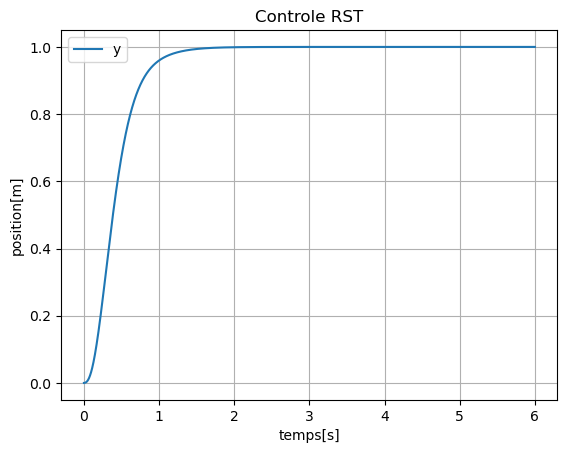

In [30]:
rst_3=RSTController(R_tf,S_tf,T_tf)
logger_rst_4 = SimLog()
logger_rst_4 = run_continuous_control_loop(hybrid_loop,rst_3,1.0,X_0,logger_rst_4)
plt.figure()
plt.plot(logger_rst_4.t_hist, logger_rst_4.y_hist, label="y")


plt.title("Controle RST")
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

#plt.savefig('Réponse_Indicielle_PID.png')
plt.show()